imports

In [122]:
from inference import get_model
import supervision as sv
import cv2
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#from sklearn.metrics import log_loss
textureModel = get_model(model_id="texture_detection-bnfjr/1",api_key="tC2EnrdOAYm1wteAYNe6")


2026-04-13 02:05:16.925581 [W:onnxruntime:, coreml_execution_provider.cc:107 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 87 number of nodes in the graph: 416 number of nodes supported by CoreML: 281


fxn to categorize images

In [42]:
def categorizeImage (fileToCategorize):
    image = cv2.imread(fileToCategorize)#link to and read image file
    result=textureModel.infer(image)[0]#refer to model, pull result
    # return [result.predictions[0].class_name, result.predictions[0].confidence] #return category and confidence
    if not result.predictions:
        return [0, 0]
    return [result.predictions[0].class_name, result.predictions[0].confidence]


images --> dataframe of categorization

In [52]:
imageFolderPath = "/Users/cecilialee/Downloads/dtd/images" #consistent image path
rows=[] # row for image name, actual texture, categorized texture, confidence
for textureFolder in os.listdir(imageFolderPath): #for image folder
    if textureFolder.startswith("."):
            continue
    textureFolderPath = os.path.join(imageFolderPath,textureFolder) #find category texture folder
    for imageName in os.listdir(textureFolderPath):#for image within category texture folder
        if imageName.startswith("."):
            continue
        imagePath = os.path.join(textureFolderPath,imageName) #determine image path
        [categorizedTexture,confidence] = categorizeImage (imagePath) # run fxn on image to find category and confidence
        rows.append([imageName, textureFolder,categorizedTexture,confidence ]) #add row noting vals
dataframe = pd.DataFrame(rows,columns=["image name","true texture", "categorized texture","confidence"]) #set column name 
print(dataframe) #print data frame
print ("done")

KeyboardInterrupt: 

categorizing the images by the model's categories

In [ ]:
#note: dataframe lists in order of "image name","true texture", "categorized texture","confidence"
textures = dict(tuple(dataframe.groupby("categorized texture"))) #determine textures by that of categorized images

categorized_images = { category: group["image name"].tolist()
                      for category, group in textures.items()} #lists of images in texture category as determined by model

#images that were unable to be categorized
total_uncategorized = (dataframe["categorized texture"] == 0).sum()
total_categorizedCorrectly = (dataframe["true texture"] == dataframe["categorized texture"]).sum()
total_categorizedIncorrectly = ((dataframe["true texture"] != dataframe["categorized texture"])&(dataframe["categorized texture"] != 0)).sum()

print("Of,",len(dataframe["categorized texture"]), "Images : ")
print("The Model was Unable to Make A Prediction for", total_uncategorized, "Images")
print("The Model was Able to Predict",total_categorizedCorrectly, "Images Correctly")
print("The Model was Able to Predict",total_categorizedIncorrectly, "Images Incorrectly")

Of, 5640 Images : 
The Model was Unable to Make A Prediction for 1036 Images
The Model was Able to Predict 4494 Images Correctly
The Model was Able to Predict 110 Images Incorrectly


error analysis

overall values:
Overall Failure to Prediction Classification : 18.368794326241133
Overall Accuracy of Prediction : 79.68085106382978
Confidence Gap : 63.898650568413494
Average Confidence (correct) : 69.71671339563864
Average Confidence (incorrect) : 5.818062827225131


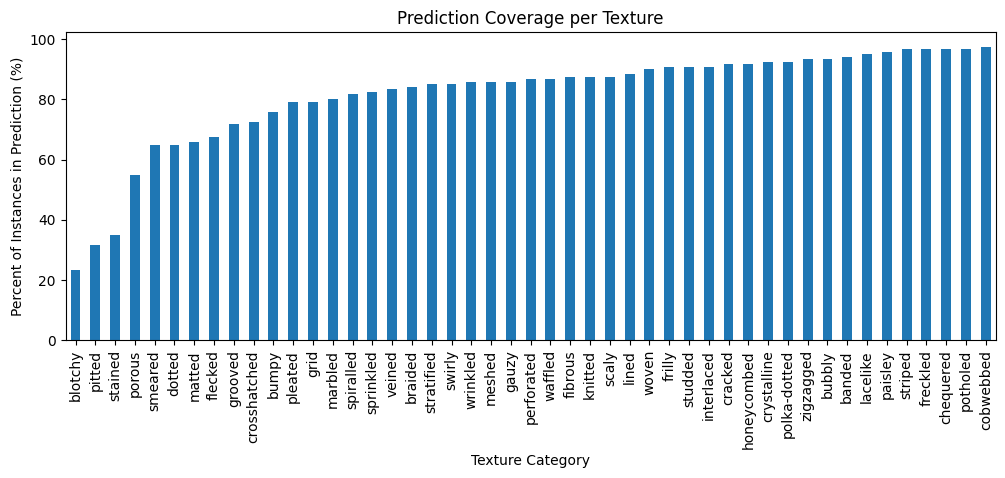

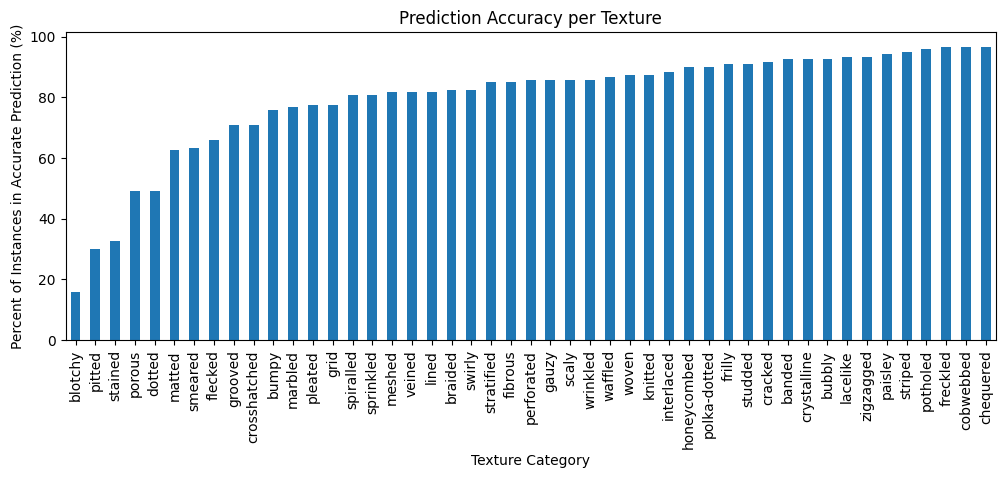

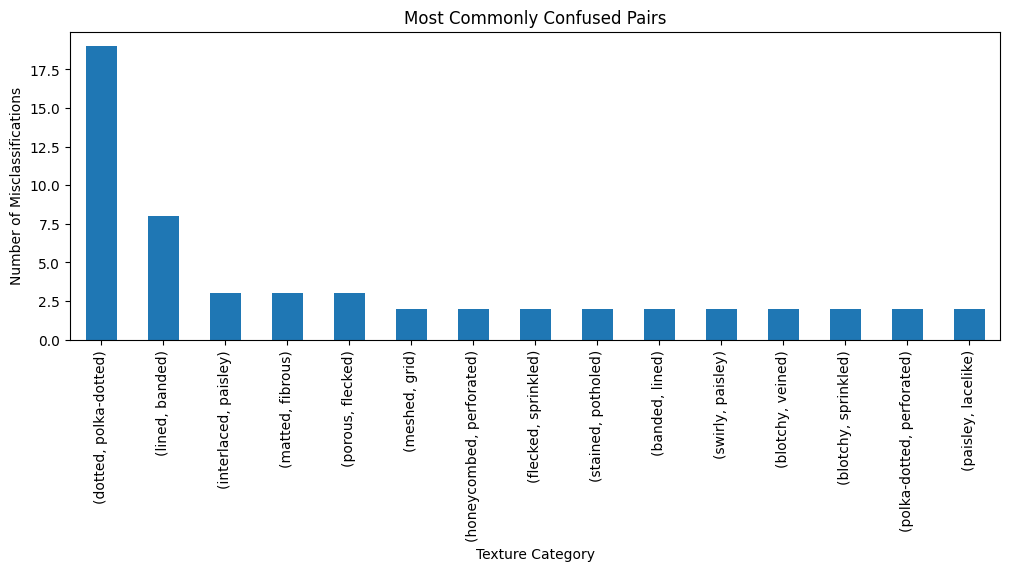

In [128]:
#accuracy per texture category
overall_accuracy = ((dataframe["categorized texture"] == dataframe["true texture"]).mean())*100
perTexture_accuracy= (dataframe.groupby("true texture").apply(
    lambda x: (x["categorized texture"] == x["true texture"]).mean())) * 100

#the textures that the model most confused w/ each other
overall_confusionMatrix = pd.crosstab(
    dataframe["true texture"], dataframe["categorized texture"])
perTexture_confusionPair = (dataframe[
    (dataframe["categorized texture"] != dataframe["true texture"]) &
    (dataframe["categorized texture"] != 0)]
    .groupby(["true texture", "categorized texture"])
    .size()
    .sort_values(ascending=False)
)

#the texture that the model was most incapable of categorizing 
overall_failure = (dataframe["categorized texture"] == 0).mean()*100
perTexture_failure = (
    dataframe[dataframe["categorized texture"] == 0]
    .groupby("true texture")
    .size()
    / (dataframe.groupby("true texture").size())*100
)
successrate = 100-perTexture_failure

#model confidence capability
dataframe["correct"] = dataframe["categorized texture"] == dataframe["true texture"]
confidence_gap = (
    dataframe[dataframe["correct"] == True]["confidence"].mean()
    - dataframe[dataframe["correct"] == False]["confidence"].mean()
)*100


print("overall values:")
print("Overall Failure to Prediction Classification :", overall_failure)
print("Overall Accuracy of Prediction :", overall_accuracy)
print("Confidence Gap :", confidence_gap)
print("Average Confidence (correct) :", dataframe[dataframe["correct"] == True]["confidence"].mean()*100)
print("Average Confidence (incorrect) :", dataframe[dataframe["correct"] == False]["confidence"].mean()*100)


successrate.sort_values().plot(kind="bar", figsize=(12,4), title="Prediction Coverage per Texture")
plt.xlabel("Texture Category")
plt.ylabel("Percent of Instances in Prediction (%)")
plt.show()
perTexture_accuracy.sort_values().plot(kind="bar", figsize=(12,4), title="Prediction Accuracy per Texture")
plt.xlabel("Texture Category")
plt.ylabel("Percent of Instances in Accurate Prediction (%)")
plt.show()
perTexture_confusionPair.head(15).plot(kind="bar", figsize=(12,4), title="Most Commonly Confused Pairs")
plt.xlabel("Texture Category")
plt.ylabel("Number of Misclassifications")
plt.show()




Texture Percent Accurate
BLAH BALH
true texture
banded          92.500000
blotchy         15.833333
braided         82.500000
bubbly          92.500000
bumpy           75.833333
chequered       96.666667
cobwebbed       96.666667
cracked         91.666667
crosshatched    70.833333
crystalline     92.500000
dotted          49.166667
fibrous         85.000000
flecked         65.833333
freckled        96.666667
frilly          90.833333
gauzy           85.833333
grid            77.500000
grooved         70.833333
honeycombed     90.000000
interlaced      88.333333
knitted         87.500000
lacelike        93.333333
lined           81.666667
marbled         76.666667
matted          62.500000
meshed          81.666667
paisley         94.166667
perforated      85.833333
pitted          30.000000
pleated         77.500000
polka-dotted    90.000000
porous          49.166667
potholed        95.833333
scaly           85.833333
smeared         63.333333
spiralled       80.833333
sprinkled       